In [1]:
from utils import load_player, f_w_v, exe_player, plot_exp,means_exp,plot_evolution, plot_interval_widths_by_player, plot_difference_by_player
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import TimeSeriesSplit

df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')

c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


##### Optimisation hyperparameters OCP

In [ ]:
players=['MHSC-06','MHSC-07','MHSC-08','MHSC-10','MHSC-11','MHSC-14','MHSC-16','MHSC-17','MHSC-18','MHSC-19',
         'MHSC-20','MHSC-22','MHSC-23','MHSC-25','MHSC-26','MHSC-29','MHSC-32','MHSC-35','MHSC-39','MHSC-41',
         'MHSC-45','MHSC-47','MHSC-49','MHSC-51','MHSC-53','MHSC-54','MHSC-55','MHSC-56','MHSC-59','MHSC-60',
         'MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-68','MHSC-69','MHSC-71','MHSC-72','MHSC-73','MHSC-75',
         'MHSC-77','MHSC-78','MHSC-79','MHSC-81']

dataset="HR"
basemodel="KR"
size_train=0.7
cv_search=5
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30 
sliding=True

alpha=0.1    
w=np.array([1])

name_methods = ["PID_log","PID_log_full_smooth","PID_log_half_smooth","PID_log_half_smooth_bis"] 
l_rs=[8,4,2,1,0.5,0.1,0.05,0.01,0.005,0.001]
q_0=range(0,21)
test_v=range(1,21)

# players=['MHSC-45']
# name_methods=["PID_log_full_smooth"]
cv_ocp = 5
best_results = {}
grid_results = {}
for player in players:
    print(player)
    best_results[player] = {}
    grid_results[player] = {}
    df_player = load_player(df, player)
    nb_observations=df_player.shape[0]
    n_train_cv = int(nb_observations*size_train)
    df_cv = df_player.iloc[:n_train_cv]
    tscv = TimeSeriesSplit(n_splits=cv_ocp)
    splits = list(tscv.split(df_cv))
    for method in name_methods:
        grid_results[player][method] = []
        for l_r in l_rs:
            for q in q_0:
                for v in test_v:
                    fold_results = []
                    for fold_id, (train_idx, test_idx) in enumerate(splits):
                        start_train = train_idx[0] + 1
                        end_train = train_idx[-1] + 1
                        start_test = test_idx[0] + 1
                        end_test = test_idx[-1] + 1
                        result = exe_player(
                            df_player,
                            player,
                            start_train,
                            end_train,
                            start_test,
                            end_test,
                            basemodel,
                            method,
                            alpha,
                            cv_search,
                            cv_method,
                            n_iter_search,
                            with_acute_load,
                            retrain_every_n_steps,
                            sliding=sliding,
                            t_burnin=30,
                            q1=q,
                            lr=l_r,
                            Csat=5,
                            KI=10,
                            f=f_w_v(w,np.array([v]),alpha)
                        )
                        cov,mean_width,median_width,std_width = means_exp(result)
                        fold_results.append({
                            "fold": fold_id,
                            "cov": cov,
                            "mean_width": mean_width,
                            "median_width": median_width,
                        })
                    mean_cov = np.mean([
                        x["cov"]
                        for x in fold_results
                    ])
                    mean_mean_width = np.mean([
                        x["mean_width"]
                        for x in fold_results
                    ])
                    mean_median_width = np.mean([
                        x["median_width"]
                        for x in fold_results
                    ])
                    grid_results[player][method].append({
                        "l_r": l_r,
                        "q_0": q,
                        "v": v,
                        "cov": mean_cov,
                        "mean_width": mean_mean_width,
                        "median_width": mean_median_width,
                    })
        results = grid_results[player][method]
        valid_results = [
            r
            for r in results
            if round(r["cov"], 2) >= 0.90
        ]
        if valid_results:
            best = min(
                valid_results,
                key=lambda r: r["mean_width"]
            )
        else:
            best = min(
                results,
                key=lambda r: (
                    -r["cov"],
                    r["mean_width"]
                )
            )
        best_results[player][method] = {
            "l_r": best["l_r"],
            "q_0": best["q_0"],
            "v": best["v"],
            "cov": best["cov"],
            "mean_width": best["mean_width"],
            "median_width": best["median_width"],
        }

with open('results/PID_grid_results.pkl', 'wb') as handle:
    pickle.dump(grid_results,handle)
    
with open('results/PID_best_hyperparams.pkl', 'wb') as handle:
    pickle.dump(best_results,handle)

MHSC-06
MHSC-07
MHSC-08
MHSC-10
MHSC-11
MHSC-14
MHSC-16
MHSC-17
MHSC-18
MHSC-19
MHSC-20
MHSC-22
MHSC-23
MHSC-25
MHSC-26
MHSC-29
MHSC-32
MHSC-35
MHSC-39
MHSC-41
MHSC-45
MHSC-47
MHSC-49
MHSC-51
MHSC-53
MHSC-54
MHSC-55
MHSC-56
MHSC-59
MHSC-60
MHSC-62
MHSC-65
MHSC-66
MHSC-67
MHSC-68
MHSC-69
MHSC-71
MHSC-72
MHSC-73
MHSC-75
MHSC-77
MHSC-78
MHSC-79
MHSC-81


In [2]:
#TODO remove (to change best_results according to grid_results without run the grid_search)
players=['MHSC-06','MHSC-07','MHSC-08','MHSC-10','MHSC-11','MHSC-14','MHSC-16','MHSC-17','MHSC-18','MHSC-19',
         'MHSC-20','MHSC-22','MHSC-23','MHSC-25','MHSC-26','MHSC-29','MHSC-32','MHSC-35','MHSC-39','MHSC-41',
         'MHSC-45','MHSC-47','MHSC-49','MHSC-51','MHSC-53','MHSC-54','MHSC-55','MHSC-56','MHSC-59','MHSC-60',
         'MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-68','MHSC-69','MHSC-71','MHSC-72','MHSC-73','MHSC-75',
         'MHSC-77','MHSC-78','MHSC-79','MHSC-81']
name_methods = ["PID_log","PID_log_full_smooth","PID_log_half_smooth","PID_log_half_smooth_bis"] 

with open('results/PID_grid_results.pkl', 'rb') as handle:
        grid_results=pickle.load(handle)
best_results = {}
for player in players:
    best_results[player] = {}
    for method in name_methods:
        results = grid_results[player][method]
        valid_results = [
            r
            for r in results
            if round(r["cov"], 2) >= 0.90
        ]
        if valid_results:
            best = min(
                valid_results,
                key=lambda r: r["mean_width"]
            )
        else:
            best = min(
                results,
                key=lambda r: (
                    -r["cov"],
                    r["mean_width"]
                )
            )
        best_results[player][method] = {
            "l_r": best["l_r"],
            "q_0": best["q_0"],
            "v": best["v"],
            "cov": best["cov"],
            "mean_width": best["mean_width"],
            "median_width": best["median_width"],
        }
with open('results/PID_best_hyperparams.pkl', 'wb') as handle:
    pickle.dump(best_results,handle)


In [ ]:
players_all=['MHSC-06','MHSC-07','MHSC-08','MHSC-10','MHSC-11','MHSC-14','MHSC-16','MHSC-17','MHSC-18','MHSC-19',
         'MHSC-20','MHSC-22','MHSC-23','MHSC-25','MHSC-26','MHSC-29','MHSC-32','MHSC-35','MHSC-39','MHSC-41',
         'MHSC-45','MHSC-47','MHSC-49','MHSC-51','MHSC-53','MHSC-54','MHSC-55','MHSC-56','MHSC-59','MHSC-60',
         'MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-68','MHSC-69','MHSC-71','MHSC-72','MHSC-73','MHSC-75',
         'MHSC-77','MHSC-78','MHSC-79','MHSC-81']

players_b=['MHSC-07','MHSC-10','MHSC-11','MHSC-18','MHSC-19','MHSC-22','MHSC-23','MHSC-25','MHSC-29','MHSC-32',
         'MHSC-39','MHSC-51','MHSC-55','MHSC-56','MHSC-59','MHSC-62','MHSC-65','MHSC-66','MHSC-67','MHSC-71',
         'MHSC-73','MHSC-75','MHSC-81']

remaining_players=[player for player in players_all if player not in players_b]

with open('results/PID_best_hyperparams.pkl', 'rb') as handle:
    best_results=pickle.load(handle)
rows=[]
dataset="HR"
basemodel="KR"
size_train=0.7
cv_search=5
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True
alpha=0.1    
w=np.array([1])
method_to_title={"PID_log":"PID","PID_log_half_smooth_bis":"r-aPID","PID_log_half_smooth":'PID Equation (9)',"PID_log_full_smooth":"PID Equation (8)"}

for player in players_all:
    print(player) 
    method_params_player=best_results[player]
    # method_params = {"PID_log":{"l_r":0.5,"q":14,"v":None},"PID_log_half_smooth_bis":{"l_r":1,"q":14,"v":np.array([14])},
    #                 "PID_log_full_smooth":{"l_r":8,"q":14,"v":np.array([18])},"PID_log_half_smooth":{"l_r":4,"q":3,"v":np.array([16])}}
    name_methods=list(method_params_player.keys())
    df_player=load_player(df,player)
    results=dict.fromkeys(name_methods)
    nb_obervations=df_player.shape[0]
    # start_train=int(nb_obervations*0.2)+1
    # end_train=start_train+int(nb_obervations*size_train)-1
    # start_test=end_train+1
    # end_test=nb_obervations
    start_train=1
    end_train=int(nb_obervations*size_train)
    start_test=end_train+1
    end_test=nb_obervations
    player_number='Player '+player.split('-')[1]
    #print(player_number)
    for method,params in method_params_player.items(): 
        result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search,cv_method,n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,t_burnin=30,q1=params["q_0"],lr=params["l_r"],Csat=5,KI=10,f=f_w_v(w,np.array([params["v"]]),alpha))
        results[method]=result
        cov,mean_width,median_width,std_width=means_exp(result)
        rows.append({"player":player_number,"method":method_to_title[method],"width_mean":mean_width,"width_median":median_width,"width_std":std_width,"coverage":cov})
        print(cov,mean_width,median_width)
        # if method in ["PID_log","PID_log_full_smooth","PID_log_half_smooth"]:
        #     print(f' & {round(cov,2)}   & {round(mean_width,1)}  & {round(median_width,1)}')
    title=f'exp1_{dataset}_{player}_{basemodel}'
    title_interval=f'exp1_{dataset}_{player}_{basemodel}_interval_evolution'
    plot_evolution(results["PID_log_half_smooth_bis"],title_interval)
    results_pid_rapid={"PID_log":results["PID_log"],"PID_log_half_smooth_bis":results["PID_log_half_smooth_bis"]}
    plot_exp(title,results_pid_rapid,["PID_log","PID_log_half_smooth_bis"],method_to_title)



Player 06
 & 0.93   & 318.4  & 363.7
 & 0.93   & 284.4  & 325.3
 & 0.93   & 268.5  & 303.9
\\
Player 07
 & 0.9   & 23.3  & 22.2
 & 0.87   & 19.7  & 18.4
 & 0.89   & 21.7  & 21.0
\\
Player 08
 & 0.9   & 28.8  & 27.3
 & 0.89   & 27.6  & 27.8
 & 0.9   & 28.3  & 27.9
\\
Player 10
 & 0.9   & 24.2  & 21.1
 & 0.86   & 20.5  & 19.5
 & 0.86   & 18.8  & 18.2
\\
Player 11
 & 0.92   & 22.0  & 18.5
 & 0.92   & 22.0  & 18.5
 & 0.92   & 21.9  & 18.4
\\
Player 14
 & 0.9   & 31.2  & 31.6
 & 0.88   & 28.9  & 28.6
 & 0.88   & 27.9  & 27.2
\\
Player 16
 & 0.9   & 26.0  & 27.2
 & 0.88   & 25.4  & 26.8
 & 0.88   & 25.5  & 25.6
\\
Player 17
 & 0.9   & 32.3  & 31.7
 & 0.89   & 31.8  & 30.2
 & 0.87   & 33.4  & 29.0
\\
Player 18
 & 0.9   & 22.4  & 22.1
 & 0.7   & 14.4  & 14.5
 & 0.72   & 14.6  & 14.1
\\
Player 19
 & 0.9   & 25.7  & 26.5
 & 0.9   & 26.4  & 25.2
 & 0.89   & 22.5  & 21.9
\\
Player 20
 & 0.91   & 39.7  & 38.9
 & 0.89   & 40.1  & 42.0
 & 0.89   & 39.3  & 40.8
\\
Player 22
 & 0.9   & 24.3  & 24.0
 & 

In [4]:
df=pd.DataFrame(rows)
df_PID=df[df['method']=="PID"]
df_raPID=df[df['method']=="r-aPID"]
mean_std_PID=df_PID["width_std"].mean()
mean_std_raPID=df_raPID["width_std"].mean()
print(mean_std_PID,mean_std_raPID)

12.295485876693762 12.061788269112519


##### Wilcoxon test

In [7]:
import scipy

df=pd.DataFrame(rows)
df_PID=df[df['method']=="PID"]
df_raPID=df[df['method']=="r-aPID"]
diff=df_raPID["width_mean"].to_numpy()-df_PID["width_mean"].to_numpy() 
stat,p=scipy.stats.wilcoxon(diff)

print("p_value =", p)
print("Median raPID-PID:", np.median(diff))
print("r-aPID > PID:", np.mean((diff > 0)))
print("r-aPID < PID:", np.mean((diff < 0)))
print("r-aPID = PID:", np.mean((diff == 0)))

p_value = 0.012996403585248117
Median raPID-PID: -1.1282743559015866
r-aPID > PID: 0.2727272727272727
r-aPID < PID: 0.7272727272727273
r-aPID = PID: 0.0


##### Graph

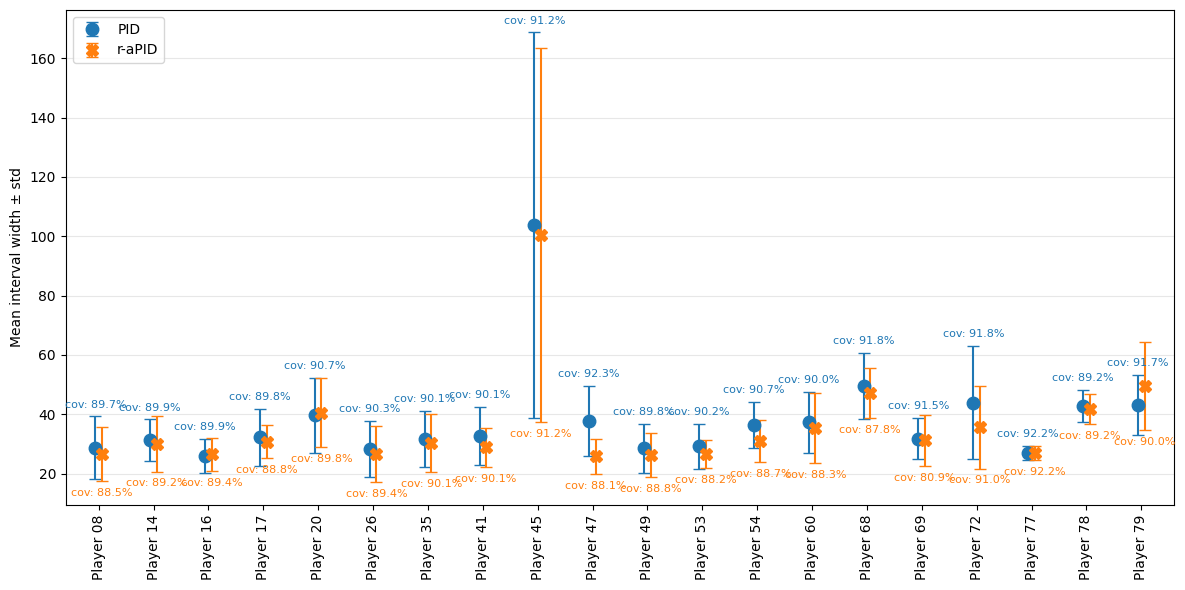

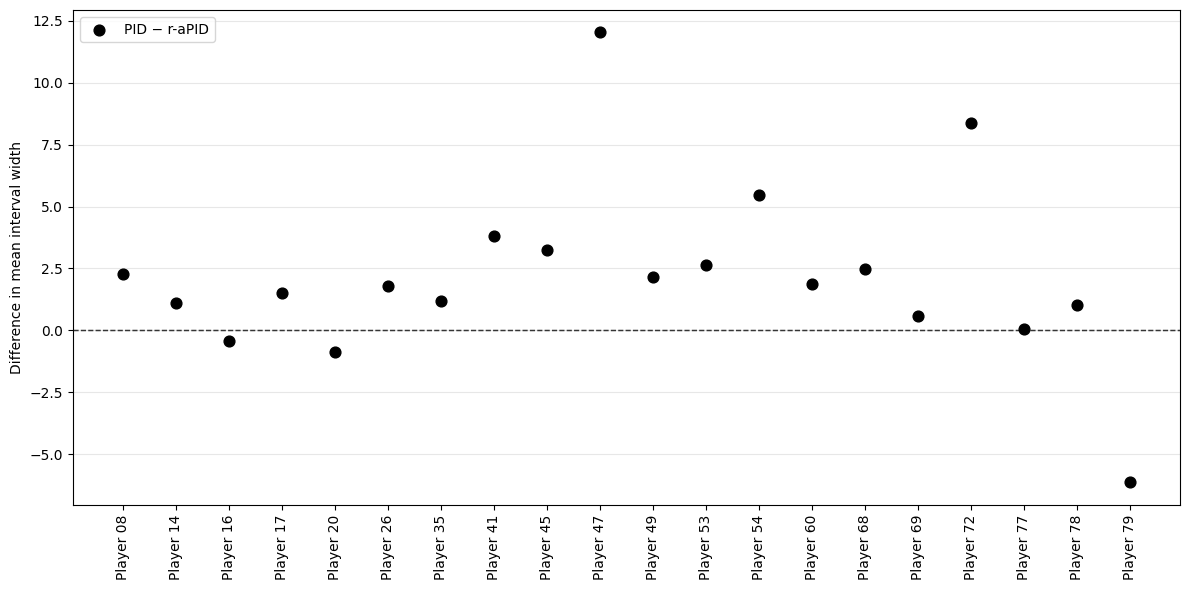

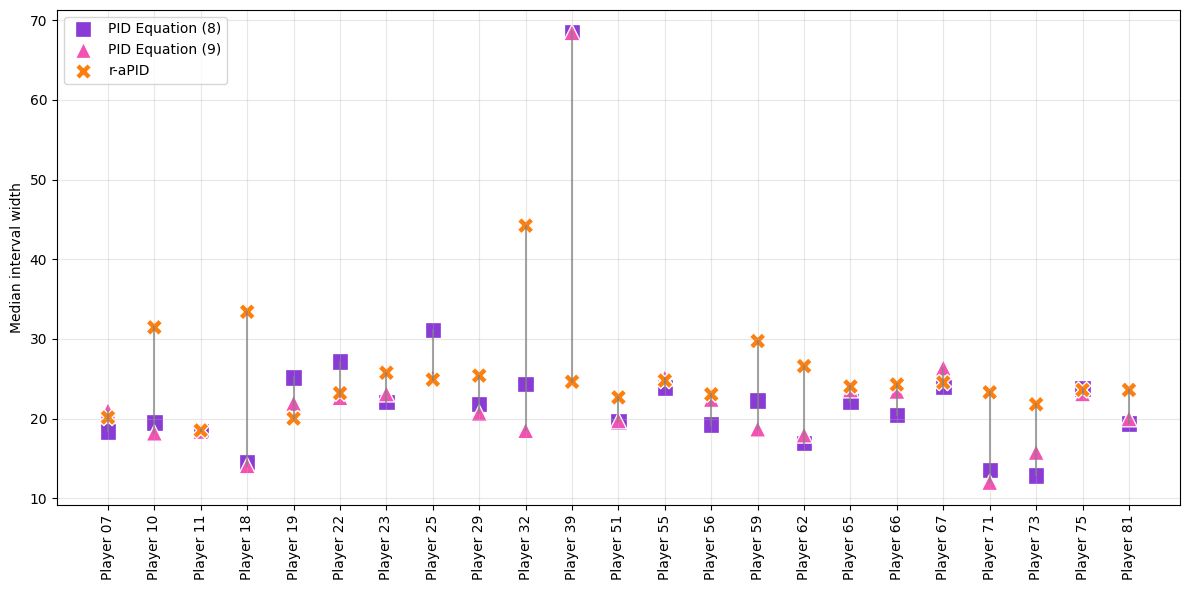

In [ ]:
methods=["PID","r-aPID"]
players=['Player 07','Player 10','Player 11','Player 18','Player 19','Player 22','Player 23','Player 25','Player 29','Player 32',
         'Player 39','Player 51','Player 55','Player 56','Player 59','Player 62','Player 65','Player 66','Player 67','Player 71',
         'Player 73','Player 75','Player 81']
players_appendix=['Player 08', 'Player 14', 'Player 16', 'Player 17', 'Player 20', 'Player 26', 'Player 35', 'Player 41', 'Player 45',
                  'Player 47', 'Player 49', 'Player 53', 'Player 54', 'Player 60', 'Player 68', 'Player 69', 'Player 72', 'Player 77', 'Player 78',
                  'Player 79']


plot_interval_widths_by_player(rows,'dumbbell_PID_raPID_rem',players_appendix,methods)
plot_difference_by_player(rows,'difference_PID_raPID_rem',methods,players_appendix)